In [266]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt

In [267]:
def ou_2d(T,dt, theta, sigma):
    # T = length of sequence
    # dt = time step size
    # sigma = how noisy it is
    # theta = how strongly it pulls towards center 

    x=np.zeros((T,2))
    x[0] = np.random.randn(2) #random initial condition

    for t in range (1,T):
        dW = np.sqrt(dt) * np.random.randn(2)
        x[t] = x[t-1] - theta*x[t-1]*dt+ sigma*dW #OU SDE
    
    return x

In [268]:
T = 1000
dt = 0.01
theta = 0.5
sigma = 0.2
seq = ou_2d(T,dt,theta,sigma)
print(seq.shape)

(1000, 2)


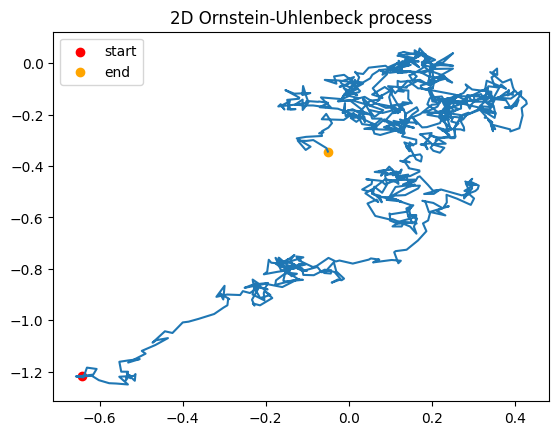

In [269]:
plt.plot(seq[:,0], seq[:,1]) #seq[:,0] = x-coord, seq[:,1] = y-coord
plt.scatter(seq[0,0], seq[0,1], color='red', label='start')
plt.scatter(seq[-1,0], seq[-1,1], color='orange', label='end')  # end
plt.legend()
plt.title("2D Ornstein-Uhlenbeck process")
plt.show()

In [270]:
def prepare_dataset(sequence, k):
    X = []
    Y = []
    for i in range(k, len(sequence)):
        X.append(sequence[i-k:i])    # prefix of length i
        Y.append(sequence[i])     # next element
    return X, Y

In [271]:
k=100
train_frac = 0.8
train_len = int(T * train_frac)
val_len = T - train_len

#creating training dataset
X_train, Y_train = [], []
for i in range(k, train_len):
    X_train.append(seq[i-k:i])
    Y_train.append(seq[i])
X_train = np.stack(X_train)
Y_train = np.stack(Y_train)

#creating validation dataset
X_val, Y_val = [], []
for i in range(train_len, T):
    X_val.append(seq[i-k:i])
    Y_val.append(seq[i])
X_val = np.stack(X_val)
Y_val = np.stack(Y_val)

In [272]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size)


In [273]:
class Transformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model) #project 2D input to d_model
        self.pos_enc = nn.Parameter(torch.randn(1,1000,d_model)) #simple learned positional encoding
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead = nhead, dim_feedforward=dim_feedforward, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, input_dim) #project back to 2D

    def forward(self, x):
        #x = [batch, seq_len, input_dim]
        x=self.input_proj(x)
        x = x + self.pos_enc[:, x.size(1), :] #add positional encoding
        x = self.transformer(x) # transformer expects [seq_len, batch, d_model]
        x = x[:, -1, :] #take output of last token
        x = self.output_proj(x)
        return x

In [274]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transformer(2, 32, 4, 2, 64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs=10

In [275]:
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            val_loss += criterion(pred, y_batch).item() * x_batch.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")


Epoch 1: Train Loss = 0.128567, Val Loss = 0.064724
Epoch 2: Train Loss = 0.048142, Val Loss = 0.017692
Epoch 3: Train Loss = 0.033638, Val Loss = 0.022946
Epoch 4: Train Loss = 0.021917, Val Loss = 0.008324
Epoch 5: Train Loss = 0.017022, Val Loss = 0.012253
Epoch 6: Train Loss = 0.014813, Val Loss = 0.010637
Epoch 7: Train Loss = 0.014070, Val Loss = 0.010333
Epoch 8: Train Loss = 0.012176, Val Loss = 0.010048
Epoch 9: Train Loss = 0.011425, Val Loss = 0.008781
Epoch 10: Train Loss = 0.009753, Val Loss = 0.009713


In [276]:
model.eval()
generated = []

# start with first k points
context = torch.tensor(seq[:k], dtype=torch.float32).unsqueeze(0).to(device)

for _ in range(T - k):  # generate every remaining step
    # model prediction (mean next step)
    next_step = model(context)
    
    # add OU-like noise
    noise = sigma * np.sqrt(dt) * torch.randn_like(next_step)
    next_step = next_step + noise
    
    # save generated step
    generated.append(next_step.detach().cpu().numpy()[0])
    
    # slide context window
    context = torch.cat([context[:, 1:, :], next_step.unsqueeze(1)], dim=1)

generated = np.array(generated)

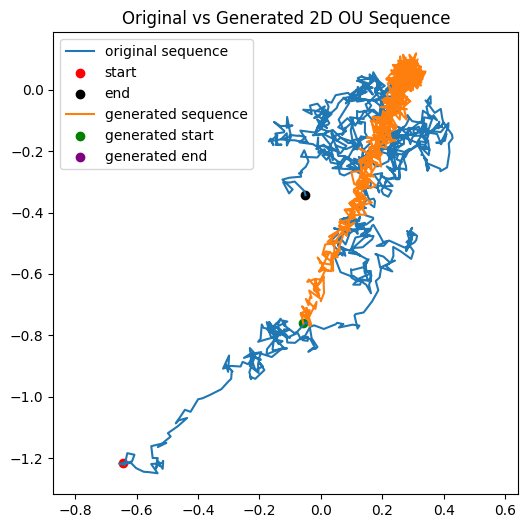

In [277]:
#generated = np.vstack([seq[:k], generated])  # shape (T, 2)

plt.figure(figsize=(6,6))

# Original OU sequence
plt.plot(seq[:,0], seq[:,1], label="original sequence")
plt.scatter(seq[0,0], seq[0,1], color='red', label='start')
plt.scatter(seq[-1,0], seq[-1,1], color='black', label='end')

# Generated sequence (from transformer)
plt.plot(generated[:,0], generated[:,1], label="generated sequence")
plt.scatter(generated[0,0], generated[0,1], color='green', label='generated start')
plt.scatter(generated[-1,0], generated[-1,1], color='purple', label='generated end')

plt.legend()
plt.title("Original vs Generated 2D OU Sequence")
plt.axis("equal")  # keep x and y scale the same
plt.show()
